In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\MiniProject\AmazonMusicClustering\Data\single_genre_artists_cleaned.csv')
df.head()

,name_song,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genres
0,La Java,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,vintage chanson
1,En Douce,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,vintage chanson
2,J'en Ai Marre,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,vintage chanson
3,Ils n'ont pas ca,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,vintage chanson
4,La belote,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,vintage chanson


# UnSupervised - K-Means Algorithm

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ['danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness',
            'valence','tempo']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

model = KMeans(n_clusters=5)
cluster = model.fit_predict(X_scaled)

# model performance - should be as low as possible 
model.inertia_
silhouette_score(X_scaled, cluster) # Overlapping cluster

0.19613780569920822

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ['danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness',
            'valence','tempo']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

for k in range(2, 11):
     model = KMeans(n_clusters=k)
     cluster = model.fit_predict(X_scaled)
     print(f'For k={k}, inertia={model.inertia_}, silhouette_score={silhouette_score(X_scaled, cluster)}')


For k=2, inertia=685952.0400559764, silhouette_score=0.21028939856145062
For k=3, inertia=573286.7222980277, silhouette_score=0.2494536064250929
For k=4, inertia=523459.06565114204, silhouette_score=0.18262894817762876
For k=5, inertia=464188.4498188512, silhouette_score=0.196219846857268
For k=6, inertia=437441.6462092193, silhouette_score=0.1957116034234018
For k=7, inertia=415629.79278141377, silhouette_score=0.16984458320434867
For k=8, inertia=399100.7448712358, silhouette_score=0.16389366182486942
For k=9, inertia=378170.71522372426, silhouette_score=0.16473208174444368
For k=10, inertia=354625.2539697113, silhouette_score=0.17292097643074814


In [2]:
# Based on the above results, we can choose k=3 or k=4 for our final model as it has a good balance of low inertia and high silhouette score.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ['danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness',
            'valence','tempo']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

model = KMeans(n_clusters=3,random_state=42,n_init=10)
clusters = model.fit_predict(X_scaled)
df['cluster'] = clusters
df

,name_song,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genres,cluster
0,La Java,0.563,0.1840,-13.757,0.0512,0.993,0.000016,0.3250,0.654,133.088,vintage chanson,2
1,En Douce,0.427,0.1800,-15.375,0.0670,0.989,0.000000,0.1280,0.431,78.459,vintage chanson,2
2,J'en Ai Marre,0.511,0.2060,-15.514,0.0592,0.995,0.000000,0.4180,0.481,70.443,vintage chanson,2
3,Ils n'ont pas ca,0.676,0.4670,-12.393,0.1650,0.991,0.000000,0.2190,0.726,129.775,vintage chanson,2
4,La belote,0.650,0.2980,-13.806,0.1380,0.991,0.000000,0.3730,0.844,75.950,vintage chanson,2
...,...,...,...,...,...,...,...,...,...,...,...,...
95832,Freaks,0.674,0.5680,-6.356,0.0408,0.116,0.000000,0.1650,0.640,166.107,alt z,0
95833,下雨天,0.528,0.6730,-3.639,0.0314,0.143,0.000000,0.0989,0.297,130.066,chinese viral pop,0
95834,The Cutest Puppy,0.609,0.0172,-28.573,0.1180,0.996,0.973000,0.1080,0.890,68.619,instrumental lullaby,2
95835,John Brown's Song,0.562,0.0331,-25.551,0.1030,0.996,0.961000,0.1110,0.386,63.696,instrumental lullaby,2


In [3]:
df['cluster'].value_counts()

cluster
0    52547
2    30692
1    12598
Name: count, dtype: int64

In [15]:
summary = df['cluster_name'].value_counts().reset_index()
summary.columns = ['Cluster Name', 'Song Count']
summary

,Cluster Name,Song Count
0,Party / Energetic,52547
1,Chill / Soft,30692
2,Rap / Spoken,12598


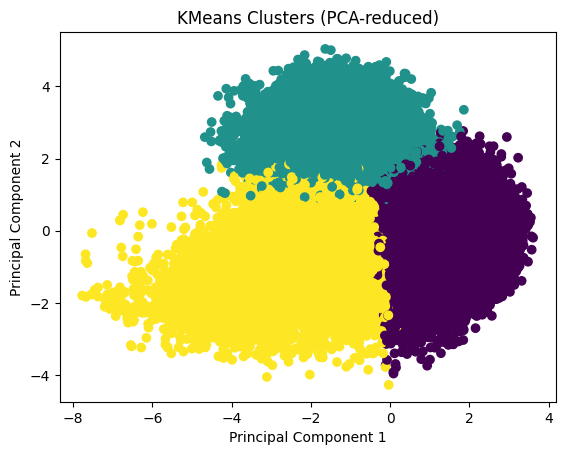

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.title('KMeans Clusters (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [51]:
from sklearn.metrics import davies_bouldin_score

score = silhouette_score(X_scaled, clusters)
print(f'Silhouette Score: {score}')

db_score = davies_bouldin_score(X_scaled, clusters)
print(f'Davies-Bouldin Score: {db_score}')

Silhouette Score: 0.24940311603289228
Davies-Bouldin Score: 1.5169351708711722


In [52]:
cluster_summary = df.groupby('cluster')[features].mean()

print("Cluster Summary (Feature Means):\n")
print(cluster_summary)

Cluster Summary (Feature Means):

         danceability    energy   loudness  speechiness  acousticness  \
cluster                                                                 
0            0.627528  0.693636  -7.607921     0.075946      0.258400   
1            0.663287  0.464306 -13.447797     0.829755      0.591264   
2            0.485842  0.311416 -13.173147     0.056574      0.748116   

         instrumentalness  liveness   valence       tempo  
cluster                                                    
0                0.050636  0.199561  0.666715  124.926834  
1                0.001649  0.441482  0.581644  100.117343  
2                0.169131  0.179434  0.413004  112.044177  


In [5]:
cluster_names = { 0: "Party / Energetic", 1: "Rap / Spoken",2: "Chill / Soft"}
df['cluster_name'] = df['cluster'].map(cluster_names)
print(df['cluster_name'].value_counts(normalize=True))

cluster_name
Party / Energetic    0.548296
Chill / Soft         0.320252
Rap / Spoken         0.131452
Name: proportion, dtype: float64


In [60]:
cluster_summary = df.groupby('cluster_name')[features].mean()

print("Cluster Summary (Feature Means):\n")
print(cluster_summary)

Cluster Summary (Feature Means):

                   danceability    energy   loudness  speechiness  \
cluster_name                                                        
Chill / Soft           0.485842  0.311416 -13.173147     0.056574   
Party / Energetic      0.627528  0.693636  -7.607921     0.075946   
Rap / Spoken           0.663287  0.464306 -13.447797     0.829755   

                   acousticness  instrumentalness  liveness   valence  \
cluster_name                                                            
Chill / Soft           0.748116          0.169131  0.179434  0.413004   
Party / Energetic      0.258400          0.050636  0.199561  0.666715   
Rap / Spoken           0.591264          0.001649  0.441482  0.581644   

                        tempo  
cluster_name                   
Chill / Soft       112.044177  
Party / Energetic  124.926834  
Rap / Spoken       100.117343  


Text(0.5, 1.0, 'Distribution of Clusters')

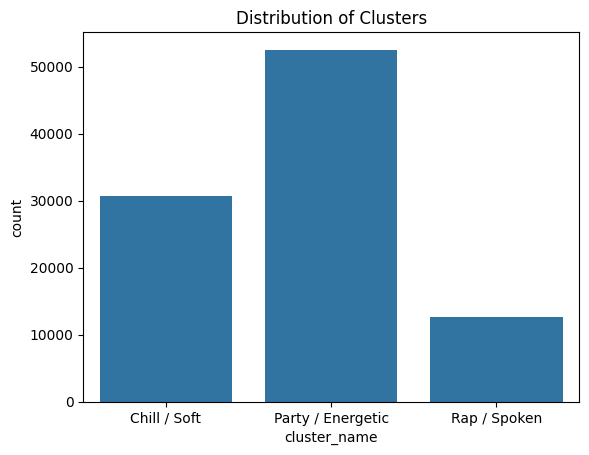

In [64]:
import seaborn as sns

sns.countplot(x='cluster_name', data=df)
plt.title('Distribution of Clusters')

Text(0.5, 1.0, 'Cluster Feature Means')

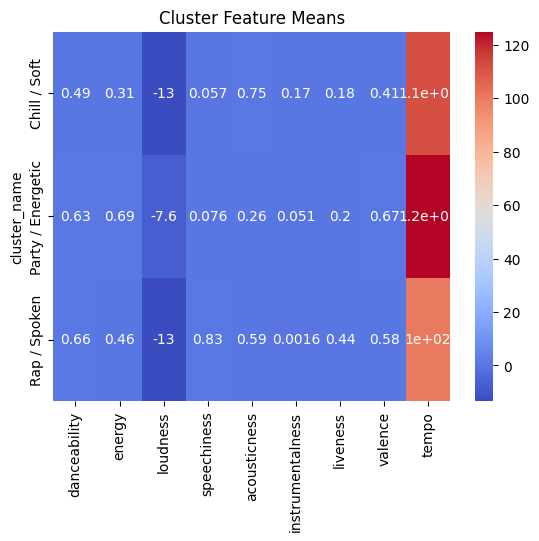

In [65]:
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm')
plt.title('Cluster Feature Means')

Text(0.5, 1.0, 'Danceability Distribution by Cluster')

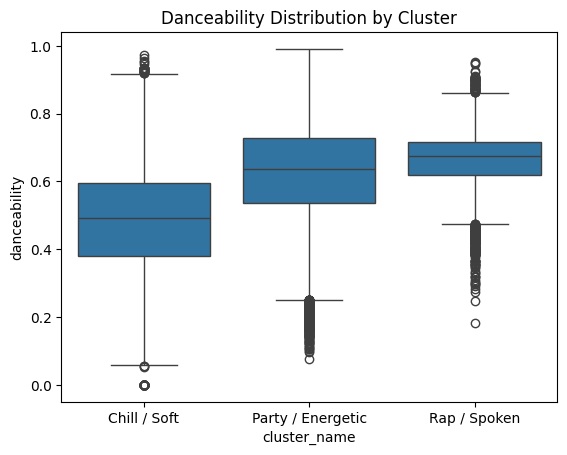

In [66]:
sns.boxplot(x='cluster_name', y='danceability', data=df)
plt.title('Danceability Distribution by Cluster')

In [16]:
df.head()

,name_song,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genres,cluster,cluster_name
0,La Java,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,vintage chanson,2,Chill / Soft
1,En Douce,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,vintage chanson,2,Chill / Soft
2,J'en Ai Marre,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,vintage chanson,2,Chill / Soft
3,Ils n'ont pas ca,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,vintage chanson,2,Chill / Soft
4,La belote,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,vintage chanson,2,Chill / Soft


In [20]:
for cluster in df['cluster_name'].unique():
    print(f"Cluster: {cluster} - Top Genres:")
    print(df[df['cluster_name'] == cluster]['genres'].value_counts().head(5))

Cluster: Chill / Soft - Top Genres:
genres
vintage taiwan pop     1047
classic israeli pop     556
chanson                 545
classic soundtrack      459
opm                     401
Name: count, dtype: int64
Cluster: Party / Energetic - Top Genres:
genres
j-pop                  813
turkish pop            631
classic thai pop       549
classic israeli pop    524
rock uruguayo          520
Name: count, dtype: int64
Cluster: Rap / Spoken - Top Genres:
genres
hoerspiel           7436
kleine hoerspiel    1931
psychedelic rock     220
barnsagor            186
poetry               173
Name: count, dtype: int64


In [ ]:
top_genres_df = (
    df.groupby('cluster_name')['genres']
      .value_counts()
      .groupby(level=0)
      .head(5)
      .reset_index(name='count')
)

st.dataframe(top_genres_df)

,cluster_name,genre,count
0,Chill / Soft,vintage taiwan pop,1047
1,Chill / Soft,classic israeli pop,556
2,Chill / Soft,chanson,545
3,Chill / Soft,classic soundtrack,459
4,Chill / Soft,opm,401
5,Party / Energetic,j-pop,813
6,Party / Energetic,turkish pop,631
7,Party / Energetic,classic thai pop,549
8,Party / Energetic,classic israeli pop,524
9,Party / Energetic,rock uruguayo,520


In [8]:
for cluster in df['cluster_name'].unique():
    print(f"Cluster: {cluster} - Songs:")
    print(df[df['cluster_name'] == cluster]['name_song'].unique().tolist()[:5])

Cluster: Chill / Soft - Songs:
['La Java', 'En Douce', "J'en Ai Marre", "Ils n'ont pas ca", 'La belote']
Cluster: Party / Energetic - Songs:
["On M'suit", "Je N'suis Pas Celle Que Vous Croyez", 'La Noce À Rebecca', 'Hotter Than That', 'Sunset Cafe Stomp']
Cluster: Rap / Spoken - Songs:
["C'est La Mode Et Voila Tout", 'Dites Moi Doumergue', "Il N'osait Pas Se Decider", "L'amour Excuse Tout", "Qu'est Ce Qu'il Faut Faire Pour Gagner Son Beefsteak"]


In [9]:
for cluster in df['cluster_name'].unique():
    print(f"Cluster: {cluster} - Songs:")
    print(df[df['cluster_name'] == cluster]['name_song'].unique().tolist())

Cluster: Chill / Soft - Songs:
['La Java', 'En Douce', "J'en Ai Marre", "Ils n'ont pas ca", 'La belote', 'Oh mademoiselle', "Il m'a vue nue", "Mon Bus'ness", "Ça c'est Paris", 'Le Fado', 'Valencia', "J'suis Nature", "Il M'a Vue Nue", "Ça C'est Paris", 'Parisette', 'La Java De Doudoune', "Tout Ça C'est Pour Vous", 'Gosse De Paris', "C'est Tout C'que J'ai", 'Rita', "J'ai Des Touches", "C'est Vrai", 'Mon homme', "Elle Prend L'boulevard Magenta", "Elle Vendait Des P'tits Gateaux", 'La Valse Du Faubourg', 'Tout Doucement À Pas De Loup', "Mam'zell Accept'rez Vous", 'Nuits De Chine', 'Les ménétriers', 'La Ronde De Nuit', 'Quand On Aime On A Toujours Vingt Ans', 'Sous Le Soleil Marocain', 'La Chanson Française', 'Le Tango Neurasthénique', "Méfiez Vous D'anatole", 'Sur La Pointe Des Pieds', 'Ma Gosse', 'Passons la monnaie', 'Par politesse', 'La plus bath des javas', 'Hortensia Ou La Fille Du Jazz Band', "L'homme Du Milieu", 'Les Absents Ont Toujours Tort', 'Jacky Apprend Le Charleston', "Y S're

In [76]:
df.to_csv(r'C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\MiniProject\AmazonMusicClustering\Data\clustered_songs.csv', index=False)

In [10]:
df

,name_song,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genres,cluster,cluster_name
0,La Java,0.563,0.1840,-13.757,0.0512,0.993,0.000016,0.3250,0.654,133.088,vintage chanson,2,Chill / Soft
1,En Douce,0.427,0.1800,-15.375,0.0670,0.989,0.000000,0.1280,0.431,78.459,vintage chanson,2,Chill / Soft
2,J'en Ai Marre,0.511,0.2060,-15.514,0.0592,0.995,0.000000,0.4180,0.481,70.443,vintage chanson,2,Chill / Soft
3,Ils n'ont pas ca,0.676,0.4670,-12.393,0.1650,0.991,0.000000,0.2190,0.726,129.775,vintage chanson,2,Chill / Soft
4,La belote,0.650,0.2980,-13.806,0.1380,0.991,0.000000,0.3730,0.844,75.950,vintage chanson,2,Chill / Soft
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95832,Freaks,0.674,0.5680,-6.356,0.0408,0.116,0.000000,0.1650,0.640,166.107,alt z,0,Party / Energetic
95833,下雨天,0.528,0.6730,-3.639,0.0314,0.143,0.000000,0.0989,0.297,130.066,chinese viral pop,0,Party / Energetic
95834,The Cutest Puppy,0.609,0.0172,-28.573,0.1180,0.996,0.973000,0.1080,0.890,68.619,instrumental lullaby,2,Chill / Soft
95835,John Brown's Song,0.562,0.0331,-25.551,0.1030,0.996,0.961000,0.1110,0.386,63.696,instrumental lullaby,2,Chill / Soft


In [85]:
df_sample = df.groupby('cluster').head(2)
df_sample

,name_song,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genres,cluster,cluster_name
0,La Java,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.3250,0.654,133.088,vintage chanson,2,Chill / Soft
1,En Douce,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.1280,0.431,78.459,vintage chanson,2,Chill / Soft
15,On M'suit,0.760,0.366,-10.173,0.0650,0.939,0.000000,0.4070,0.846,129.074,vintage chanson,0,Party / Energetic
31,C'est La Mode Et Voila Tout,0.592,0.408,-11.585,0.2710,0.993,0.000002,0.4130,0.766,81.126,vintage chanson,1,Rap / Spoken
34,Je N'suis Pas Celle Que Vous Croyez,0.650,0.520,-12.068,0.0817,0.953,0.000000,0.0629,0.888,131.367,vintage chanson,0,Party / Energetic
37,Dites Moi Doumergue,0.710,0.561,-12.736,0.4720,0.955,0.000000,0.2130,0.963,78.705,vintage chanson,1,Rap / Spoken


In [86]:
df.groupby('cluster').apply(lambda x: x.sample(2)).reset_index(drop=True)

C:\Users\nisha\AppData\Local\Temp\ipykernel_27064\503210753.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('cluster').apply(lambda x: x.sample(2)).reset_index(drop=True)


,name_song,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genres,cluster,cluster_name
0,Som v tom,0.724,0.541,-7.157,0.0262,0.468,0.00000,0.0869,0.582,111.421,slovak pop,0,Party / Energetic
1,Czarny ląd,0.480,0.393,-12.236,0.1070,0.423,0.00271,0.1090,0.754,185.367,polish jazz,0,Party / Energetic
2,075 - Lösegeld am Henkersberg - Teil 19,0.624,0.438,-10.920,0.6480,0.393,0.00000,0.7630,0.573,99.352,kleine hoerspiel,1,Rap / Spoken
3,017 - Die Doppelgängerin - Teil 18,0.680,0.578,-13.158,0.9360,0.770,0.00000,0.4910,0.705,86.893,kleine hoerspiel,1,Rap / Spoken
4,Sentimento,0.603,0.396,-9.762,0.0288,0.283,0.00000,0.1230,0.290,91.913,italian folk,2,Chill / Soft
5,Oriental Strut,0.540,0.254,-11.859,0.0823,0.995,0.49300,0.1750,0.473,183.916,new orleans jazz,2,Chill / Soft


In [11]:
df['cluster_name'].value_counts()

cluster_name
Party / Energetic    52547
Chill / Soft         30692
Rap / Spoken         12598
Name: count, dtype: int64

In [14]:
dataset_df = df.groupby('cluster').apply(lambda x: x.sample(5)).reset_index(drop=True)
dict = {'name_song': 'Song Name', 'danceability': 'Danceability', 'energy': 'Energy', 'loudness': 'Loudness',
        'speechiness': 'Speechiness', 'acousticness': 'Acousticness', 'instrumentalness': 'Instrumentalness',
        'liveness': 'Liveness', 'valence': 'Valence', 'tempo': 'Tempo', 'genres': 'Genres', 'cluster': 'Cluster',
        'cluster_name': 'Cluster Name'}
dataset_df.rename(columns=dict,
          inplace=True)
dataset_df

C:\Users\nisha\AppData\Local\Temp\ipykernel_32256\828024999.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataset_df = df.groupby('cluster').apply(lambda x: x.sample(5)).reset_index(drop=True)


,Song Name,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Genres,Cluster,Cluster Name
0,Wisdom,0.547,0.6140,-5.801,0.0233,0.2280,0.000451,0.1300,0.233,97.438,vancouver indie,0,Party / Energetic
1,"If It's Tuesday, This Must Be Belgium",0.485,0.5250,-11.643,0.0400,0.3150,0.011200,0.2480,0.747,91.825,nederpop,0,Party / Energetic
2,Spanish Town,0.750,0.3420,-14.206,0.0366,0.0242,0.000024,0.0969,0.249,108.535,pub rock,0,Party / Energetic
3,Banho De Lua (Tintarella Di Luna) - 1994 Remaster,0.747,0.6200,-9.373,0.1180,0.5230,0.000027,0.1740,0.877,146.330,jovem guarda,0,Party / Energetic
4,Mi Tío Mario Veterinario,0.789,0.8100,-4.839,0.0281,0.2920,0.000024,0.3710,0.975,121.945,musica para ninos,0,Party / Energetic
5,053 - Schüsse aus der Rosenhecke - Teil 09,0.658,0.5550,-11.399,0.9570,0.2780,0.000000,0.4190,0.502,76.583,kleine hoerspiel,1,Rap / Spoken
6,023 - Kampf der Spione - Teil 03,0.572,0.3880,-13.475,0.7880,0.6330,0.000000,0.4390,0.345,106.279,kleine hoerspiel,1,Rap / Spoken
7,Kapitel 40 - Der Weihnachtstraum (Folge 052),0.704,0.2280,-15.129,0.9510,0.4880,0.000000,0.4310,0.493,132.366,hoerspiel,1,Rap / Spoken
8,Story: Enöga & Skattkistan,0.633,0.4410,-14.946,0.8980,0.4420,0.000000,0.4490,0.591,112.987,barnmusik,1,Rap / Spoken
9,Kapitel 11 - und die Schule (Folge 006),0.706,0.2110,-20.394,0.9520,0.1520,0.000000,0.2190,0.457,86.499,hoerspiel,1,Rap / Spoken


In [13]:
df.columns

Index(['name_song', 'danceability', 'energy', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'genres', 'cluster', 'cluster_name'],
      dtype='object')